In [ ]:
import torch
import histonCNN_with_res_gru as md
from trainers import simple_trainer_with_embed
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from models import simple_multi_dimensional_cnn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Generate data from a simple mathematical equation.

$$
\text{score}_b =
\sum_{i=1}^{W}
\Big(
\sin(2.5\,X_{b,0,i}) \cdot \cos(X_{b,1,i})
+ \tfrac{1}{2}X_{b,2,i}^{3}
- e^{-X_{b,3,i}^{2}}
\Big)
$$

In [18]:
import torch

# Dimensions
B = 10000   # batch size
C = 4      # channels
W = 500    # width

# Random input
X = torch.randn(B, C, W)

# Nonlinear score
score = (
    torch.sin(2.5 * X[:, 0, :]) * torch.cos(X[:, 1, :])
    + 0.5 * X[:, 2, :] ** 3
    - torch.exp(-X[:, 3, :] ** 2)
).sum(dim=1)

# Binary labels
y = (score > 0).long()

print(X.shape)  # torch.Size([1000, 4, 20])
print(y.shape)  # torch.Size([1000])

torch.Size([10000, 4, 500])
torch.Size([10000])


In [22]:
# Note
# Regression tasks cannot be run with return_probs = True
#When residual blocks are used stride should be 1

# Define model parameters.
data_tensor = X
targets = y.unsqueeze(1)
batch_size = 100
n_epochs = 100
mode = 'classify'


if mode == 'regress':
	return_probs = False
else: 
	return_probs = True
conv_params = [5,1,1]


#Split to tranin and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    data_tensor, targets,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

#Convert to torch datasets
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# Split datasets to batches and convert datasets to data loaders
train_loader = DataLoader(train_dataset, batch_size=500, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=500, shuffle=False)


# # First run the model for the multichannel_tensor
# simple_cnn = simple_multi_dimensional_cnn(input_len = data_tensor.shape[2],
# 									channels=data_tensor.shape[1],
# 									hist_param_list=[3,1,1],
#                                     return_embedding=True)

# Define the model.
model = md.histonCNN_with_res_gru(input_channels = C,
                  batch_size = 20, histon_len = W,
                  target_dim = 1,
                    hist_param_list = conv_params,
                    averaging_window = False,
                    res_blocks = False,
                    use_gru = False, return_embeddings=True)

#Define the trainer.
simple_cnn_trainer = simple_trainer_with_embed(model=model,
							lr=1e-6,epochs = n_epochs,
							train_loader=train_loader, test_loader=test_loader, mode=mode,
                            stopper_delta=0.0001, return_probs=return_probs, use_early_stopping=True)


#Train the model on the train set.
result = simple_cnn_trainer.train() 


 15%|█▌        | 15/100 [00:15<01:29,  1.06s/it]

Restoring best model weights.


In [23]:
if mode == 'classify':
	cnn_test_acc, epoch_mean_batch_acc, losses, epoch_mean_test_losses, trained_model, total_predictions, total_test_labels, probs, xembed = result
elif mode == 'regress':
	cnn_test_acc, epoch_mean_batch_acc, losses, epoch_mean_test_losses, trained_model, total_predictions, total_test_labels, xembed = result


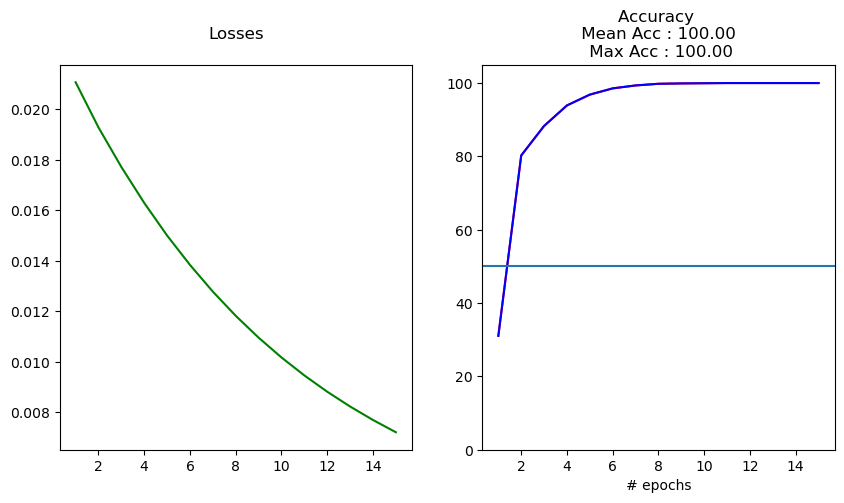

In [24]:
########################################################################################################################################
########################################################################################################################################
########################################################################################################################################
########################################################################################################################################
# Plot the loss and the accuracy of the model


fig, axes = plt.subplots(nrows=1, ncols=2, figsize = (10,5))
ax1, ax2 = axes.flatten()
ax1.set_title('Losses\n')
ax1.plot(list(range(1,len(losses) + 1)),losses, c = 'green',
             linestyle='-')
# ax1.scatter(x = list(range(1,n_epochs + 1)),y = loss, c = 'green')

mean_acc = f"{(np.mean(cnn_test_acc[-2:]).item()):.2f}"
max_acc = f"{(np.max(cnn_test_acc).item()):.2f}"

if mode == 'classify':
	ax2.set_title(f'Accuracy \n Mean Acc : {mean_acc} \n Max Acc : {max_acc}')
	ax2.set_ylim((0,105))
	ax2.set_xlabel('# epochs')
	ax2.plot( list(range(1,len(cnn_test_acc) + 1)), cnn_test_acc, c = 'red', label = 'train_acc')
	# ax2.scatter(x = list(range(1,n_epochs + 1)), y = acc)
	ax2.plot( list(range(1,len(cnn_test_acc) + 1)), cnn_test_acc, c = 'blue', label = 'test_acc')
	ax2.axhline(50)


elif mode == 'regress':
		ax2.set_title(f'Accuracy \n Mean Acc : {mean_acc} \n Max Acc : {max_acc}')
		ax2.set_ylim((0,1.05))
		ax2.set_xlabel('# epochs')
		ax2.plot( list(range(1,len(cnn_test_acc) + 1)), cnn_test_acc, c = 'red', label = 'train_acc')
		# ax2.scatter(x = list(range(1,n_epochs + 1)), y = acc)
		ax2.plot( list(range(1,len(cnn_test_acc) + 1)), cnn_test_acc, c = 'blue', label = 'test_acc')
		